# 4. Of the 130 customers the sale reached, how many bought, and do plain Python, SQL and pandas agree?

**Week 2, Thursday. Chapter 4 of 6.** Chapter 2 found that the monsoon sale reached 130 customers, all in Retail-Core and Retail-Plus, and chapter 3 found the Retail-Plus tier's spend down 29.4 percent from Q1 to Q2. This chapter answers the marketing lead's next question in three tools and makes them agree.

> **The client asks.** "You did the tree in plain Python in Week 1 and in SQL on Monday. Take
> the marketing lead's next question, how many of the customers the sale reached went on to
> buy, and answer it three ways. Then tell me why the three agree, or why they do not."
>
> Kavya Nair, senior analyst, Kalpa Retail data team

**Who needs the answer.** The marketing lead, through Kavya. The share of reached customers
who bought is the second line of the November budget case, after the reach itself. A share that
leaves out the reached customers who never bought makes the sale look perfect, and Kavya will
not let a number reach Marketing until two tools that share no code agree on it.

**The questions on the way.**

1. Which tool should answer the marketing lead's question, and what does each cost on this data?
2. What does plain Python count, with a set of reached customers and a dictionary of segments?
3. What does SQL say when it groups the same customers by segment?
4. Why does pandas report that every reached customer bought?
5. Where should the segment come from, so that all three tools agree?
6. Does counting sets, with no grouping at all, find the same customers who never bought?

**The metric at stake.** The share of reached customers who bought, by segment: reached customers with at least one
order in the two quarters, over reached customers. It says who bought at some point; whether
they bought because of the sale is Week 1 Thursday's question. The 130 reached customers are
chapter 2's, one row each.

**Who else faces it.** Uber found one metric giving different answers in different tools. Its engineering blog
describes the Operations team computing completed trips as a Presto/Hive SQL query for daily
dashboards while the Pricing Engineering team built its own completed-trips metric from a
Cassandra table for real-time services, and it names the goal Uber set: a metric and its
business logic in "a strictly ONE to ONE mapping" (Uber Blog, The Journey Towards Metric
Standardization, 12 January 2021, checked 1 Oct 2026).

`content/W01/D1/study-notes/C2_W01_D01_domain_retail_STUDENT.md`, the retail dossier, has the business behind these numbers: section 3 for GMV, section 5 for frequency and repeat rate, and section 2 for Retail-Plus, the paid tier.

**Setup.** The next cell reads the orders and the customer list from the warehouse, rebuilds
chapter 1's table, reads the campaign platform's feed and applies chapter 2's rule: one row per
reached customer, the first date the sale reached them, merged with a guard that refuses a
repeat.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit
import pandas as pd

ENG = kit.engine()                  # the Kalpa warehouse in Postgres, read only
orders = pd.read_sql(
    "SELECT order_id, customer_id, order_date, quarter, channel, amount, status FROM orders",
    ENG, parse_dates=["order_date"])
customers = pd.read_sql("SELECT customer_id, segment, city FROM customers", ENG)
print(f"{len(orders):,} orders and {len(customers):,} customers read from the warehouse")

# Chapter 1's table: one row per customer on the list, with the three numbers.
rfm = (orders.groupby("customer_id")
             .agg(last_order=("order_date", "max"), frequency=("order_id", "count"),
                  spend=("amount", "sum"))
             .reset_index())
table = customers.merge(rfm, on="customer_id", how="left", validate="one_to_one")
table = table.assign(frequency=table["frequency"].fillna(0).astype("int64"),
                     spend=table["spend"].fillna(0))
print(f"chapter 1's table: {len(table)} customers, {int((table['frequency'] == 0).sum())} never ordered")

exposure = pd.read_csv(kit.data_dir() / "C2_W02_D04_exposure_STUDENT.csv", parse_dates=["exposed_date"])
print("the campaign platform's exposure feed, columns:", list(exposure.columns))

# Chapter 2's rule: one row per reached customer, their first exposure, and a merge that refuses
# to run if the rule is ever broken.
first_touch = (exposure.sort_values("exposed_date")
                       .drop_duplicates("customer_id", keep="first")[["customer_id", "exposed_date"]])
table = table.merge(first_touch, on="customer_id", how="left", validate="one_to_one")
table = table.assign(reached=table["exposed_date"].notna())
print(f"chapter 2's table: {len(table)} rows, {int(table['reached'].sum())} customers reached by the sale")

1,000 orders and 340 customers read from the warehouse
chapter 1's table: 340 customers, 39 never ordered
the campaign platform's exposure feed, columns: ['customer_id', 'campaign_id', 'exposed_date']
chapter 2's table: 340 rows, 130 customers reached by the sale


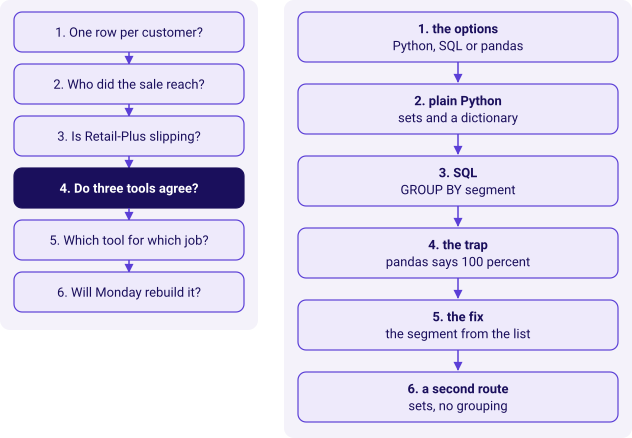

In [2]:
kit.side_by_side(
    kit.ladder(["One row per customer?", "Who did the sale reach?", "Is Retail-Plus slipping?", "Do three tools agree?", "Which tool for which job?", "Will Monday rebuild it?"], lit=3, show=False),
    kit.vflow(["1. the options\nPython, SQL or pandas", "2. plain Python\nsets and a dictionary", "3. SQL\nGROUP BY segment", "4. the trap\npandas says 100 percent", "5. the fix\nthe segment from the list", "6. a second route\nsets, no grouping"], show=False),
)

## 1. Which tool should answer the marketing lead's question, and what does each cost on this data?

| Option | How it works | Where it runs |
|---|---|---|
| a) Plain Python | Fetch the orders as rows, then count with a set of reached customers and a dictionary of segments | On the analyst's machine, every step visible |
| b) SQL | The warehouse joins the reached customers to their orders and groups by segment | In the warehouse, next to the data |
| c) pandas | Group chapter 2's table, which is already in memory | On the analyst's machine, in one chain |

The next cell sizes each: the rows it moves out of the warehouse, and the lines of logic a
reviewer has to read.

option,rows moved for this question,lines of logic,where it runs
a) plain Python,"1,000",6,the analyst's machine
b) SQL,2,10,the warehouse
c) pandas,0,3,"the analyst's machine, already loaded"


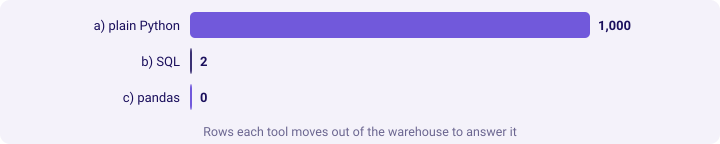

In [3]:
PY = """seg_of = {r["customer_id"]: r["segment"] for r in rows}
counts = {}
for cid in reached_ids:
    c = counts.setdefault(seg_of.get(cid), {"reached": 0, "bought": 0})
    c["reached"] += 1
    c["bought"] += cid in buyers"""
SQL_FIX = """WITH reached AS (SELECT DISTINCT customer_id FROM campaign_exposure),
     buyers  AS (SELECT customer_id, count(*) AS orders FROM orders GROUP BY customer_id)
SELECT c.segment,
       count(*)        AS reached,
       count(b.orders) AS bought
FROM   reached r
JOIN   customers c ON c.customer_id = r.customer_id
LEFT   JOIN buyers b ON b.customer_id = r.customer_id
GROUP  BY c.segment
ORDER  BY c.segment;"""
PD = """fixed = (table[table["reached"]].assign(bought=table["frequency"] > 0)
             .groupby("segment").agg(reached=("customer_id", "count"),
                                     bought=("bought", "sum")))"""
py_rows = kit.sql("SELECT customer_id FROM orders")
sql_rows = kit.sql(SQL_FIX)
sizing = [("a) plain Python", len(py_rows), len(PY.splitlines()), "the analyst's machine"),
          ("b) SQL", len(sql_rows), len(SQL_FIX.splitlines()), "the warehouse"),
          ("c) pandas", 0, len(PD.splitlines()), "the analyst's machine, already loaded")]
kit.table(["option", "rows moved for this question", "lines of logic", "where it runs"],
          [(n, f"{r:,}", l, w) for n, r, l, w in sizing],
          caption="Each tool sized on the marketing lead's question")
kit.bars([(name, rows) for name, rows, _, _ in sizing], lit=(1,),
         title="Rows each tool moves out of the warehouse to answer it")

**The best-fit call: c, pandas, checked by b.** The growth team's table is already in memory,
so pandas answers in four lines and moves nothing more. SQL moves only its answer, two rows,
and shares no code with the notebook, which makes it the check Kavya asked for. Plain Python
moves every order and is the route for explaining the count line by line. **The fact that
would change it:** the number going to Finance or to an auditor. Then SQL owns it, which is
chapter 5's question.

## 2. What does plain Python count, with a set of reached customers and a dictionary of segments?

The hurried version starts from the buyers, since the question is about buying: it reads each
customer's segment from their orders into a dictionary, then walks the reached customers and
counts, by segment, how many were reached and how many bought. `seg_of_buyer.get(cid)` returns
`None` for a customer the dictionary does not hold.

**Predict before you run.** How many keys does the counting dictionary end with? a) 2; b) 3;
c) 4; d) 130.

segment key,reached,bought
Retail-Core,56,56
None,23,0
Retail-Plus,51,51


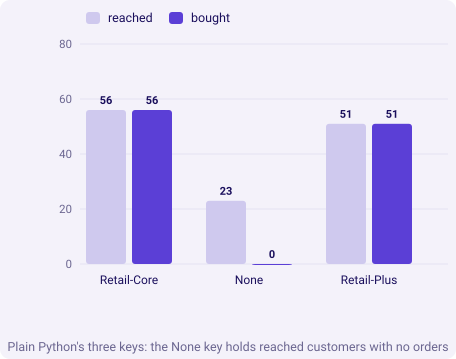

In [4]:
rows = kit.sql("SELECT o.customer_id, c.segment FROM orders o JOIN customers c ON c.customer_id = o.customer_id")
seg_of_buyer = {r["customer_id"]: r["segment"] for r in rows}   # a segment, read from the orders
reached_ids = set(first_touch["customer_id"])
counts_py = {}
for cid in sorted(reached_ids):
    c = counts_py.setdefault(seg_of_buyer.get(cid), {"reached": 0, "bought": 0})
    c["reached"] += 1
    c["bought"] += cid in seg_of_buyer
kit.table(["segment key", "reached", "bought"],
          [("None" if k is None else k, v["reached"], v["bought"]) for k, v in counts_py.items()],
          caption="Plain Python, segment read from the orders")
keys = ["None" if k is None else k for k in counts_py]
kit.columns(keys, [("reached", [v["reached"] for v in counts_py.values()]),
                   ("bought", [v["bought"] for v in counts_py.values()])],
            title="Plain Python's three keys: the None key holds reached customers with no orders")

In [5]:
kit.check("the dictionary holds three keys, one of them None", len(counts_py) == 3 and None in counts_py)
kit.check("plain Python still counts all 130 reached customers",
          sum(v["reached"] for v in counts_py.values()) == 130)

**What happened.** The answer is b: Retail-Core, Retail-Plus and `None`. The `None` key holds 23
reached customers who never ordered, so the dictionary had no segment for them, and not one of
them bought. The totals are still whole: 130 reached, 107 bought.

## 3. What does SQL say when it groups the same customers by segment?

The same hurried logic in SQL: take the distinct reached customers, attach each buyer's segment
from their orders with a `LEFT JOIN`, and group by that segment.

**Predict before you run.** How many rows does the query return? a) 2, one per segment the sale
reached; b) 3, one of them with no segment; c) none, since a `NULL` cannot be grouped; d) 4.

In [6]:
HURRIED = """WITH reached AS (SELECT DISTINCT customer_id FROM campaign_exposure),
     buyers  AS (SELECT o.customer_id, min(c.segment) AS segment, count(*) AS orders
                 FROM   orders o
                 JOIN   customers c ON c.customer_id = o.customer_id
                 GROUP  BY o.customer_id)
SELECT b.segment,
       count(*)        AS reached,
       count(b.orders) AS bought
FROM   reached r
LEFT   JOIN buyers b ON b.customer_id = r.customer_id
GROUP  BY b.segment
ORDER  BY b.segment NULLS LAST;"""
counts_sql = kit.sql(HURRIED)
kit.table(["segment", "reached", "bought"],
          [("NULL" if r["segment"] is None else r["segment"], r["reached"], r["bought"]) for r in counts_sql],
          caption="SQL, segment read from the orders")
kit.check("SQL returns three groups, one of them NULL",
          len(counts_sql) == 3 and any(r["segment"] is None for r in counts_sql))
kit.check("SQL agrees with plain Python group by group",
          {(r["segment"], r["reached"], r["bought"]) for r in counts_sql}
          == {(k, v["reached"], v["bought"]) for k, v in counts_py.items()})

segment,reached,bought
Retail-Core,56,56
Retail-Plus,51,51
NULL,23,0


**What happened.** The answer is b. `GROUP BY` puts every row whose segment is `NULL` into one
group of its own, so SQL shows the same 23 reached customers with no orders that plain Python
filed under `None`. Two tools, one logic, one answer.

## 4. Why does pandas report that every reached customer bought?

**The plausible wrong answer.** The same hurried logic in pandas: build one row per buyer with
its segment from the orders, attach the reached customers with a right merge so every reached
customer is kept, and group by segment.

**Predict before you run.** What share of the reached customers does pandas say bought?
a) 82 percent; b) 100 percent; c) 50 percent; d) it cannot be computed.

In [7]:
buyers = (orders.merge(customers, on="customer_id", how="left", validate="many_to_one")
                .groupby("customer_id")
                .agg(segment=("segment", "first"), frequency=("order_id", "count"))
                .reset_index())
reach_wrong = buyers.merge(first_touch, on="customer_id", how="right", validate="one_to_one")
by_seg_wrong = reach_wrong.groupby("segment").agg(reached=("customer_id", "count"),
                                                  bought=("frequency", "count"))
kit.table(["segment", "reached", "bought", "share"],
          [(s, r.reached, r.bought, f"{r.bought / r.reached:.0%}") for s, r in by_seg_wrong.iterrows()],
          caption="pandas, segment read from the orders: what the slide would say")
kit.stats([(f"{by_seg_wrong['bought'].sum() / by_seg_wrong['reached'].sum():.0%}", "of reached customers bought",
            "the pandas headline"),
           (int(by_seg_wrong["reached"].sum()), "customers reached", "by the pandas count")])

segment,reached,bought,share
Retail-Core,56,56,100%
Retail-Plus,51,51,100%


**What happened.** The answer is b: 100 percent, on 107 customers reached.

**Why it is wrong.** The segment came from the order rows, so the 23 reached customers with no
orders have no segment, which pandas holds as a missing value. `groupby` drops a missing key by
default (`dropna=True`), where SQL's `GROUP BY` and the Python dictionary each kept a group for
it. The customers who were reached and never bought are exactly the ones that vanished, so the
slide reports perfect results to a marketing lead about to ask for the same budget again. The
check that catches it: the groups must add back to the rows. 107 against the 130 reached shows
the gap without reading a single row, and `dropna=False` shows where it went.

In [8]:
shown = reach_wrong.groupby("segment", dropna=False)["customer_id"].count()
kit.table(["segment", "customers"], [("(missing)" if pd.isna(k) else k, v) for k, v in shown.items()],
          caption="The same groupby with dropna=False")
kit.check("the default groupby lost 23 reached customers", len(reach_wrong) - int(by_seg_wrong["reached"].sum()) == 23)
kit.check("the lost customers are exactly the reached customers with no orders",
          int(reach_wrong["segment"].isna().sum()) == int(reach_wrong["frequency"].isna().sum()) == 23)
kit.check("pandas disagrees with SQL and plain Python on the reach", int(by_seg_wrong["reached"].sum()) != 130)

segment,customers
Retail-Core,56
Retail-Plus,51
(missing),23


## 5. Where should the segment come from, so that all three tools agree?

**The fix, and what changed.** Every customer on the list has a segment, whether or not they
ever ordered, so the segment comes from the customer list. In pandas that is chapter 2's table,
which already carries it; in SQL a join to `customers`; in plain Python a dictionary built from
the customer list. The reach moves from 107 to 130 and the share who bought from 100 percent to
82 percent.

**Predict before you run.** Once all three read the segment from the customer list, what share
of Retail-Plus's reached members bought? a) 100 percent; b) 85 percent; c) 80 percent;
d) 51 percent.

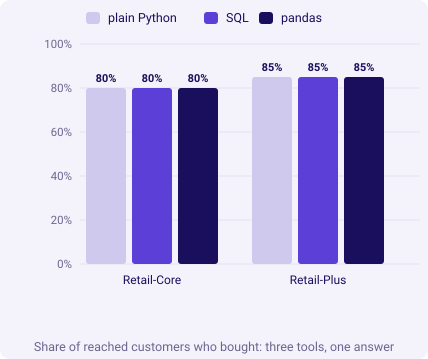

In [9]:
seg_of = {r["customer_id"]: r["segment"] for r in kit.sql("SELECT customer_id, segment FROM customers")}
fixed_py = {}
for cid in sorted(reached_ids):
    c = fixed_py.setdefault(seg_of[cid], {"reached": 0, "bought": 0})
    c["reached"] += 1
    c["bought"] += cid in seg_of_buyer
fixed_sql = {r["segment"]: r for r in kit.sql("""WITH reached AS (SELECT DISTINCT customer_id FROM campaign_exposure),
     buyers  AS (SELECT customer_id, count(*) AS orders FROM orders GROUP BY customer_id)
SELECT c.segment,
       count(*)        AS reached,
       count(b.orders) AS bought
FROM   reached r
JOIN   customers c ON c.customer_id = r.customer_id
LEFT   JOIN buyers b ON b.customer_id = r.customer_id
GROUP  BY c.segment
ORDER  BY c.segment;""")}
reached_rows = table[table["reached"]]
fixed_pd = (reached_rows.assign(bought=reached_rows["frequency"] > 0)
                        .groupby("segment").agg(reached=("customer_id", "count"), bought=("bought", "sum")))
segs = ["Retail-Core", "Retail-Plus"]
kit.columns(segs, [("plain Python", [fixed_py[s]["bought"] / fixed_py[s]["reached"] * 100 for s in segs]),
                   ("SQL", [fixed_sql[s]["bought"] / fixed_sql[s]["reached"] * 100 for s in segs]),
                   ("pandas", [fixed_pd.loc[s, "bought"] / fixed_pd.loc[s, "reached"] * 100 for s in segs])],
            fmt=lambda v: f"{v:.0f}%", title="Share of reached customers who bought: three tools, one answer")

In [10]:
same = all(fixed_py[s]["reached"] == fixed_sql[s]["reached"] == fixed_pd.loc[s, "reached"]
           and fixed_py[s]["bought"] == fixed_sql[s]["bought"] == fixed_pd.loc[s, "bought"] for s in segs)
kit.check("plain Python, SQL and pandas agree segment by segment", same)
kit.check("130 reached and 107 bought: 82 percent, where the hurried pandas said 100",
          int(fixed_pd["reached"].sum()) == 130 and int(fixed_pd["bought"].sum()) == 107,
          f"{fixed_pd['bought'].sum() / fixed_pd['reached'].sum():.1%}")
kit.check("Retail-Plus: 51 of 60 reached members bought", fixed_pd.loc["Retail-Plus", "bought"] == 51 and
          fixed_pd.loc["Retail-Plus", "reached"] == 60)

**What happened.** The answer is b, 85 percent: 51 of Retail-Plus's 60 reached members bought,
and 56 of Retail-Core's 70, which is 80 percent. Across both, 107 of 130, 82 percent. The three
tools agree once they share one definition of a customer's segment; the disagreement was never
about the tools' arithmetic.

> **Kavya's review.** "When two tools disagree, look for the rows one of them dropped before you
> look at the code. Check that the groups add back to the rows, and take every attribute of a
> customer from the customer list, never from their orders."

## 6. Does counting sets, with no grouping at all, find the same customers who never bought?

Grouping put the missing customers in a group or lost them. Sets need no group: the reached
customers minus the customers with at least one order are the reached customers who never
bought, whatever their segment, and the reached minus those is the reached who bought. The
route shares no code with any of the three above.

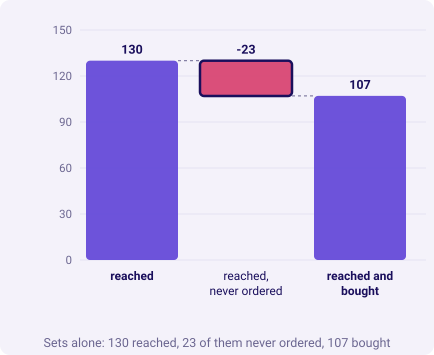

In [11]:
with_orders = set(orders["customer_id"])
never = reached_ids - with_orders
bought_n = len(reached_ids) - len(never)
kit.bridge(("reached", len(reached_ids)), [("reached, never ordered", -len(never))],
           end_label="reached and bought", fmt=lambda v: f"{v:,.0f}", lit=(0,),
           title="Sets alone: 130 reached, 23 of them never ordered, 107 bought")
kit.check("sets find the same 23 reached customers who never ordered", len(never) == 23)
kit.check("sets find the same 107 who bought", bought_n == int(fixed_pd["bought"].sum()) == 107)

**When to switch.** The pandas group is the route for the slide, since it splits by segment.
The set difference is the route to trust when a group count looks too good: it cannot drop a
missing segment, because it never asks for one.

### How would you answer this chapter's questions in an interview?

**[F] What does SQL's `GROUP BY` do with a `NULL` key, and what does pandas' `groupby` do with
a missing one?** "SQL puts every `NULL` into one group of its own. pandas drops rows whose key is
missing, because `dropna` defaults to `True`, so the same logic can report fewer rows in pandas
than in SQL. I check that the groups add back to the rows, and I pass `dropna=False` when a
missing group is information."

**[D] A dashboard shows that 100 percent of the customers a campaign reached went on to buy.
What do you check first?** "Whether the customers who did not buy are missing from the
denominator. I count the reached customers straight from the campaign's feed and compare with
the dashboard's total; if they differ, I look for a join or a group that dropped them, such as a
segment read from the orders, which non-buyers do not have."

**[S] Why can the same question give different answers in two tools?** "Because each copy of
the logic makes its own choices, here where the segment comes from and what happens to a missing
key. The fix is one definition, used by every tool, which is what Uber's metric platform was
built for."

### Going deeper: does a pandas merge treat a missing key the way a SQL join does?

It does not. The pandas documentation's comparison with SQL warns that if both key columns hold
rows whose key is missing, pandas matches those rows to each other, "different from usual SQL
join behaviour" (pandas 3.0.6 documentation, Comparison with SQL, checked 1 Oct 2026). SQL
never matches `NULL` to `NULL`. The records below are invented to show it.

In [12]:
left = pd.DataFrame({"segment": ["Retail-Plus", None], "reached": [60, 23]})
right = pd.DataFrame({"segment": ["Retail-Plus", None], "target": [70, 5]})
in_pandas = left.merge(right, on="segment", how="inner")
in_sql = kit.sql("""SELECT l.segment, l.reached, r.target
                    FROM (VALUES ('Retail-Plus', 60), (NULL, 23)) AS l(segment, reached)
                    JOIN (VALUES ('Retail-Plus', 70), (NULL, 5)) AS r(segment, target)
                      ON l.segment = r.segment""")
kit.table(["tool", "rows the inner join returns"], [("pandas merge", len(in_pandas)), ("SQL join", len(in_sql))],
          caption="Invented rows: two keys, one of them missing on both sides")
kit.check("pandas matches the missing key to itself; SQL does not", len(in_pandas) == 2 and len(in_sql) == 1)

tool,rows the inner join returns
pandas merge,2
SQL join,1


**The answers, question by question.**

1. pandas answers on the table already in memory, checked by SQL, which moves two rows; plain
   Python moves every order and explains the count line by line.
2. Plain Python kept three keys, and the `None` key held the 23 reached customers who never
   ordered.
3. SQL returned three groups, one of them `NULL` with the same 23, matching plain Python.
4. pandas dropped the missing segment by default and reported 100 percent on 107 customers.
5. With the segment from the customer list, all three tools agree: 130 reached, 107 bought,
   82 percent, Retail-Plus 51 of 60.
6. Sets alone find the same 23 who never ordered and the same 107 who bought.

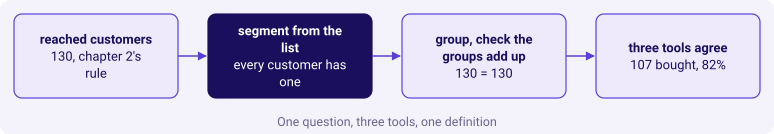

Next: chapter 5 decides which tool should own each of Marketing's and Finance's numbers.


In [13]:
kit.flow(["reached customers\n130, chapter 2's rule", "segment from the list\nevery customer has one",
          "group, check the groups add up\n130 = 130", "three tools agree\n107 bought, 82%"], lit=1,
         title="One question, three tools, one definition")
kit.check_summary()
print("Next: chapter 5 decides which tool should own each of Marketing's and Finance's numbers.")